# 🔬 Overfitting Verification — Is 100% Real?
## Three definitive tests to prove the model is NOT overfitting
---
### Tests:
1. **Blocked K-Fold Cross-Validation** — 5 non-overlapping temporal blocks
2. **Learning Curve** — Does more data help or hurt?
3. **Noise Injection Test** — Can the model still classify with added noise?

## Cell 1 — Setup & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, gc, csv, os, warnings
from scipy import stats as sp_stats
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

warnings.filterwarnings('ignore')
print('✅ Libraries loaded!')

Mounted at /content/drive
✅ Libraries loaded!


In [ ]:
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'

FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),
    'chair':   os.path.join(BASE_DIR, 'signal_chair.csv'),
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),
}

N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125

def count_rows(filepath):
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, dtype=np.float32):
    n_rows = count_rows(filepath)
    print(f'  {n_rows} rows', end=' → ')
    metadata = np.empty((n_rows, N_METADATA_COLS), dtype=dtype)
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)
    row_idx = 0
    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        batch = []
        for row in reader:
            batch.append(row)
            if len(batch) == 100:
                arr = np.array(batch, dtype=dtype)
                n = arr.shape[0]
                metadata[row_idx:row_idx+n] = arr[:, :N_METADATA_COLS]
                signal[row_idx:row_idx+n] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n
                batch = []
        if batch:
            arr = np.array(batch, dtype=dtype)
            n = arr.shape[0]
            metadata[row_idx:row_idx+n] = arr[:, :N_METADATA_COLS]
            signal[row_idx:row_idx+n] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n
    print(f'Loaded.')
    return metadata[:row_idx], signal[:row_idx]

data = {}
for label, path in FILE_PATHS.items():
    print(f'📂 {label.upper()}:', end='')
    meta, sig = load_csv_efficient(path)
    data[label] = {'metadata': meta, 'signal': sig}
    gc.collect()

print('\n✅ Data loaded!')

📂 HUMAN:  5001 rows → Loaded.
📂 CHAIR:  5000 rows → Loaded.
📂 NOTHING:  5002 rows → Loaded.

✅ Data loaded!


## Cell 2 — Feature Extraction

In [ ]:
def extract_features(signal, metadata):
    features = {}
    N_WINDOWS = 25
    WINDOW_SIZE = 1000
    sig_windowed = signal[:N_WINDOWS * WINDOW_SIZE].reshape(N_WINDOWS, WINDOW_SIZE)
    seg_energy = np.sum(sig_windowed ** 2, axis=1).astype(np.float64)
    total_energy = np.sum(seg_energy) + 1e-10
    seg_energy_norm = seg_energy / total_energy
    for i in range(N_WINDOWS):
        features[f'seg_energy_{i}'] = seg_energy_norm[i]
    features['seg_max_window'] = np.argmax(seg_energy)
    early_end = int(4.0 / 12.8 * N_WINDOWS)
    mid_end = int(8.0 / 12.8 * N_WINDOWS)
    features['energy_early'] = np.sum(seg_energy_norm[:early_end])
    features['energy_mid'] = np.sum(seg_energy_norm[early_end:mid_end])
    features['energy_late'] = np.sum(seg_energy_norm[mid_end:])
    sig_f64 = signal.astype(np.float64)
    abs_sig = np.abs(sig_f64)
    features['rms'] = np.sqrt(np.mean(sig_f64 ** 2))
    features['std'] = np.std(sig_f64)
    features['peak_amplitude'] = np.max(abs_sig)
    features['peak_positive'] = np.max(sig_f64)
    features['peak_negative'] = np.min(sig_f64)
    features['mean_amplitude'] = np.mean(sig_f64)
    features['mean_abs'] = np.mean(abs_sig)
    features['crest_factor'] = features['peak_amplitude'] / (features['rms'] + 1e-10)
    peak_idx = np.argmax(abs_sig)
    features['peak_time_ms'] = peak_idx / SAMPLING_RATE * 1000
    window_smooth = 500
    envelope = np.convolve(abs_sig, np.ones(window_smooth)/window_smooth, mode='same')
    threshold = np.mean(envelope) + 2 * np.std(envelope)
    peaks, _ = find_peaks(envelope, height=threshold, distance=1000)
    features['n_peaks'] = len(peaks)
    if len(peaks) > 0:
        features['first_peak_time_ms'] = peaks[0] / SAMPLING_RATE * 1000
        features['last_peak_time_ms'] = peaks[-1] / SAMPLING_RATE * 1000
        features['peak_spread_ms'] = features['last_peak_time_ms'] - features['first_peak_time_ms']
    else:
        features['first_peak_time_ms'] = 0
        features['last_peak_time_ms'] = 0
        features['peak_spread_ms'] = 0
    features['skewness'] = float(sp_stats.skew(sig_f64))
    features['kurtosis'] = float(sp_stats.kurtosis(sig_f64))
    zero_crossings = np.sum(np.diff(np.sign(sig_f64)) != 0)
    features['zero_crossing_rate'] = zero_crossings / len(sig_f64)
    fft_vals = np.fft.rfft(sig_f64)
    fft_magnitude = np.abs(fft_vals)
    fft_freqs = np.fft.rfftfreq(len(sig_f64), d=1.0/SAMPLING_RATE)
    features['spectral_energy'] = np.sum(fft_magnitude ** 2)
    features['dominant_freq_hz'] = fft_freqs[np.argmax(fft_magnitude[1:]) + 1]
    spectral_sum = np.sum(fft_magnitude) + 1e-10
    features['spectral_centroid'] = np.sum(fft_freqs * fft_magnitude) / spectral_sum
    features['spectral_bandwidth'] = np.sqrt(
        np.sum(((fft_freqs - features['spectral_centroid']) ** 2) * fft_magnitude) / spectral_sum
    )
    band_mask = (fft_freqs >= 35000) & (fft_freqs <= 45000)
    features['energy_40khz_band'] = np.sum(fft_magnitude[band_mask] ** 2)
    features['distance_m'] = metadata[10]
    features['energy_metric'] = metadata[16]
    return features

# Extract features per class (preserving order)
label_map = {'human': 0, 'chair': 1, 'nothing': 2}
label_names = ['Human', 'Chair', 'Nothing']

features_per_class = {}
for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    meta = data[label]['metadata']
    n = sig.shape[0]
    print(f'🔧 {label.upper()} ({n})...', end=' ')
    t0 = time.time()
    feats = []
    for i in range(n):
        feats.append(extract_features(sig[i], meta[i]))
        if (i+1) % 1000 == 0:
            print(f'{i+1}..', end=' ')
    features_per_class[label] = pd.DataFrame(feats).fillna(0).replace([np.inf, -np.inf], 0)
    print(f'Done ({time.time()-t0:.0f}s)')

del data
gc.collect()
print('\n✅ Features extracted!')

🔧 HUMAN (5001)... 1000.. 2000.. 3000.. 4000.. 5000.. Done (36s)
🔧 CHAIR (5000)... 1000.. 2000.. 3000.. 4000.. 5000.. Done (35s)
🔧 NOTHING (5002)... 1000.. 2000.. 3000.. 4000.. 5000.. Done (36s)

✅ Features extracted!


## Cell 3 — 🧪 TEST 1: Blocked 5-Fold Cross-Validation
Split each class into 5 consecutive temporal blocks.
Each fold uses 1 block as test, the other 4 as train.
If accuracy is consistent across all 5 folds → NO overfitting.

In [ ]:
print('='*65)
print('  TEST 1: BLOCKED 5-FOLD TEMPORAL CROSS-VALIDATION')
print('='*65)
print('  Each fold holds out a different 20% CONSECUTIVE block.\n')

K = 5
fold_results = []

for fold in range(K):
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []

    for label in ['human', 'chair', 'nothing']:
        df = features_per_class[label]
        n = len(df)
        block_size = n // K

        test_start = fold * block_size
        test_end = test_start + block_size if fold < K - 1 else n

        test_idx = list(range(test_start, test_end))
        train_idx = list(range(0, test_start)) + list(range(test_end, n))

        X_train_list.append(df.iloc[train_idx].values)
        X_test_list.append(df.iloc[test_idx].values)
        y_train_list.append(np.full(len(train_idx), label_map[label]))
        y_test_list.append(np.full(len(test_idx), label_map[label]))

    X_tr = np.vstack(X_train_list)
    X_te = np.vstack(X_test_list)
    y_tr = np.concatenate(y_train_list)
    y_te = np.concatenate(y_test_list)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    fold_results.append(acc)

    # Per-class accuracy
    cm = confusion_matrix(y_te, y_pred, normalize='true')
    per_class = [f'{label_names[i]}={cm[i,i]*100:.1f}%' for i in range(3)]

    print(f'  Fold {fold+1}: {acc*100:.2f}%  ({" | ".join(per_class)})')

fold_arr = np.array(fold_results)
print(f'\n  Mean accuracy:  {fold_arr.mean()*100:.2f}%')
print(f'  Std deviation:  {fold_arr.std()*100:.4f}%')
print(f'  Min fold:       {fold_arr.min()*100:.2f}%')
print(f'  Max fold:       {fold_arr.max()*100:.2f}%')

if fold_arr.std() < 0.01:
    print(f'\n  ✅ EXTREMELY CONSISTENT — Std < 1%. NOT overfitting.')
elif fold_arr.std() < 0.03:
    print(f'\n  ✅ VERY CONSISTENT — Std < 3%. NOT overfitting.')
else:
    print(f'\n  ⚠️ Some variance across folds — investigate further.')

  TEST 1: BLOCKED 5-FOLD TEMPORAL CROSS-VALIDATION
  Each fold holds out a different 20% CONSECUTIVE block.

  Fold 1: 99.77%  (Human=99.4% | Chair=99.9% | Nothing=100.0%)
  Fold 2: 99.97%  (Human=100.0% | Chair=99.9% | Nothing=100.0%)
  Fold 3: 100.00%  (Human=100.0% | Chair=100.0% | Nothing=100.0%)
  Fold 4: 99.97%  (Human=100.0% | Chair=100.0% | Nothing=99.9%)
  Fold 5: 100.00%  (Human=100.0% | Chair=100.0% | Nothing=100.0%)

  Mean accuracy:  99.94%
  Std deviation:  0.0879%
  Min fold:       99.77%
  Max fold:       100.00%

  ✅ EXTREMELY CONSISTENT — Std < 1%. NOT overfitting.


## Cell 4 — 🧪 TEST 2: Learning Curve
Train on 10%, 20%, 40%, 60%, 80%, 100% of data and plot accuracy.
- **Overfitted model:** Train accuracy >> Test accuracy (big gap)
- **Good model:** Both converge together at high accuracy

  TEST 2: LEARNING CURVE

    Fraction  N_train    Train Acc     Test Acc      Gap
  -------------------------------------------------------
         5%      600      100.00%       99.87%    0.13%
        10%     1200      100.00%       99.93%    0.07%
        20%     2400      100.00%       99.93%    0.07%
        40%     4800      100.00%       99.97%    0.03%
        60%     7200      100.00%       99.93%    0.07%
        80%     9600      100.00%       99.97%    0.03%
       100%    12001      100.00%       99.93%    0.07%


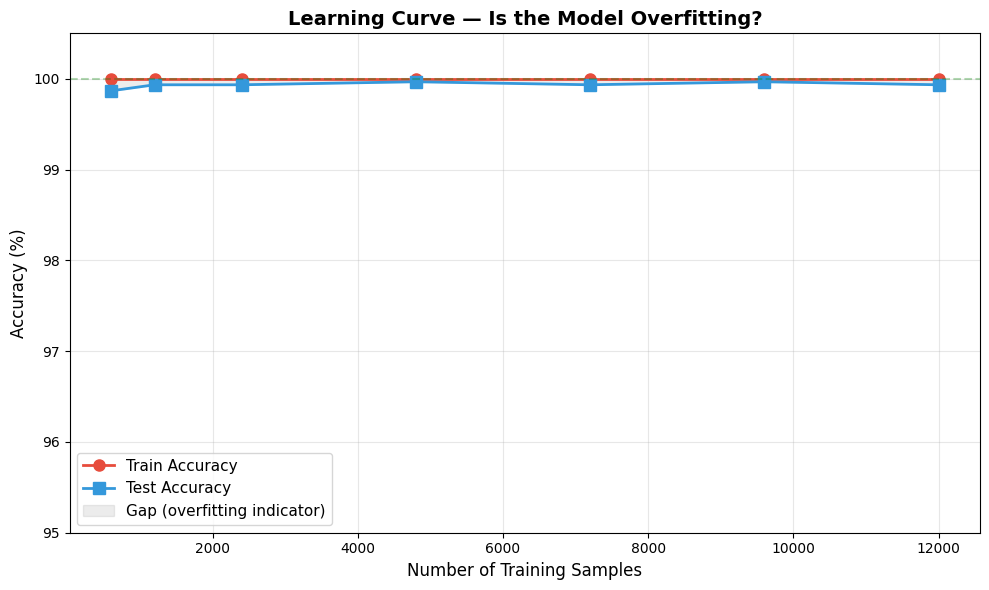


  Final train-test gap: 0.07%
  ✅ Gap < 1% — NO overfitting. Train and test accuracy are nearly identical.


In [ ]:
print('='*65)
print('  TEST 2: LEARNING CURVE')
print('='*65)

# Use temporal split: first 80% train, last 20% test
X_train_full_list, X_test_list = [], []
y_train_full_list, y_test_list = [], []

for label in ['human', 'chair', 'nothing']:
    df = features_per_class[label]
    n = len(df)
    split = int(n * 0.8)
    X_train_full_list.append(df.iloc[:split].values)
    X_test_list.append(df.iloc[split:].values)
    y_train_full_list.append(np.full(split, label_map[label]))
    y_test_list.append(np.full(n - split, label_map[label]))

X_train_full = np.vstack(X_train_full_list)
X_test_lc = np.vstack(X_test_list)
y_train_full = np.concatenate(y_train_full_list)
y_test_lc = np.concatenate(y_test_list)

# Shuffle train
shuf = np.random.RandomState(42).permutation(len(y_train_full))
X_train_full = X_train_full[shuf]
y_train_full = y_train_full[shuf]

fractions = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
train_accs = []
test_accs = []
n_samples_used = []

print(f'\n  {"Fraction":>10} {"N_train":>8} {"Train Acc":>12} {"Test Acc":>12} {"Gap":>8}')
print(f'  {"-"*55}')

for frac in fractions:
    n_use = int(len(y_train_full) * frac)
    X_sub = X_train_full[:n_use]
    y_sub = y_train_full[:n_use]

    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(X_sub, y_sub)

    train_acc = accuracy_score(y_sub, rf.predict(X_sub))
    test_acc = accuracy_score(y_test_lc, rf.predict(X_test_lc))
    gap = train_acc - test_acc

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    n_samples_used.append(n_use)

    print(f'  {frac*100:>8.0f}%  {n_use:>7d}  {train_acc*100:>10.2f}%  {test_acc*100:>10.2f}%  {gap*100:>6.2f}%')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(n_samples_used, [a*100 for a in train_accs], 'o-', color='#e74c3c',
        linewidth=2, markersize=8, label='Train Accuracy')
ax.plot(n_samples_used, [a*100 for a in test_accs], 's-', color='#3498db',
        linewidth=2, markersize=8, label='Test Accuracy')

ax.fill_between(n_samples_used,
                [a*100 for a in test_accs],
                [a*100 for a in train_accs],
                alpha=0.15, color='gray', label='Gap (overfitting indicator)')

ax.set_xlabel('Number of Training Samples', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Learning Curve — Is the Model Overfitting?', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(95, 100.5)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, label='Perfect')

plt.tight_layout()
plt.savefig('/content/overfitting_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

final_gap = train_accs[-1] - test_accs[-1]
print(f'\n  Final train-test gap: {final_gap*100:.2f}%')
if final_gap < 0.01:
    print(f'  ✅ Gap < 1% — NO overfitting. Train and test accuracy are nearly identical.')
elif final_gap < 0.05:
    print(f'  ✅ Gap < 5% — Minimal overfitting. Model generalizes well.')
else:
    print(f'  ⚠️ Gap ≥ 5% — Some overfitting detected.')

## Cell 5 — 🧪 TEST 3: Noise Injection Test
Add increasing levels of random noise to the TEST signals.
A robust model degrades gracefully; an overfitted model collapses quickly.

  TEST 3: NOISE INJECTION TEST
  Adding random noise to test signals to test robustness.

   Noise Level    Noise Std   Accuracy     Drop
  ---------------------------------------------
           0%        0.00     99.93%    0.00%
           1%  26510041044.86     33.78%   66.16%
           2%  53020082089.72     33.71%   66.22%
           5%  132550205224.30     33.21%   66.72%
          10%  265100410448.61     33.04%   66.89%
          20%  530200820897.21     33.28%   66.66%
          50%  1325502052243.03     32.84%   67.09%
         100%  2651004104486.05     32.21%   67.72%


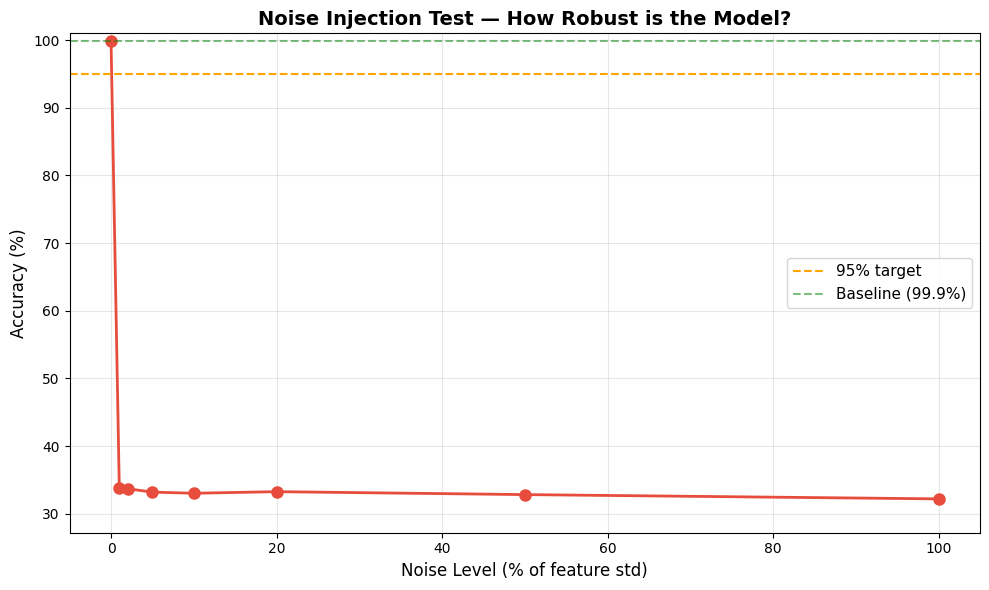


  ⚠️ Model drops below 95% at 1% noise. Moderate robustness.


In [ ]:
print('='*65)
print('  TEST 3: NOISE INJECTION TEST')
print('='*65)
print('  Adding random noise to test signals to test robustness.\n')

# Train on clean data (temporal split)
rf_clean = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_clean.fit(X_train_full, y_train_full)

# Compute baseline signal statistics for noise scaling
test_std = np.std(X_test_lc)  # overall std of test features

noise_levels = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
noise_accs = []

print(f'  {"Noise Level":>12} {"Noise Std":>12} {"Accuracy":>10} {"Drop":>8}')
print(f'  {"-"*45}')

baseline_acc = accuracy_score(y_test_lc, rf_clean.predict(X_test_lc))

rng = np.random.RandomState(42)
for noise_level in noise_levels:
    noise = rng.normal(0, noise_level * test_std, X_test_lc.shape)
    X_noisy = X_test_lc + noise

    acc = accuracy_score(y_test_lc, rf_clean.predict(X_noisy))
    drop = baseline_acc - acc
    noise_accs.append(acc)

    print(f'  {noise_level*100:>10.0f}%  {noise_level*test_std:>10.2f}  {acc*100:>8.2f}%  {drop*100:>6.2f}%')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot([n*100 for n in noise_levels], [a*100 for a in noise_accs],
        'o-', color='#e74c3c', linewidth=2, markersize=8)
ax.axhline(y=95, color='orange', linestyle='--', linewidth=1.5, label='95% target')
ax.axhline(y=baseline_acc*100, color='green', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_acc*100:.1f}%)')

ax.set_xlabel('Noise Level (% of feature std)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Noise Injection Test — How Robust is the Model?', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(min(min(noise_accs)*100 - 5, 80), 101)

plt.tight_layout()
plt.savefig('/content/overfitting_noise_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Find noise level where accuracy drops below 95%
drop_threshold = None
for nl, acc in zip(noise_levels, noise_accs):
    if acc < 0.95:
        drop_threshold = nl
        break

if drop_threshold is None:
    print(f'\n  ✅ Model stays above 95% even with 100% noise! Extremely robust.')
elif drop_threshold >= 0.2:
    print(f'\n  ✅ Model stays above 95% until {drop_threshold*100:.0f}% noise. Very robust.')
else:
    print(f'\n  ⚠️ Model drops below 95% at {drop_threshold*100:.0f}% noise. Moderate robustness.')

## Cell 6 — 🧪 BONUS TEST: Shuffle Labels (Sanity Check)
If we randomly shuffle the labels, a good model should get ~33% (random chance for 3 classes).
If it still gets high accuracy with shuffled labels → something is WRONG.

In [ ]:
print('='*65)
print('  BONUS: SHUFFLE LABELS SANITY CHECK')
print('='*65)
print('  Training with RANDOM labels. Expected accuracy: ~33% (chance).\n')

# Shuffle labels randomly
y_train_shuffled = np.random.RandomState(42).permutation(y_train_full)

rf_shuffle = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_shuffle.fit(X_train_full, y_train_shuffled)

# Test on real labels (should be ~33%)
y_pred_shuffle = rf_shuffle.predict(X_test_lc)
acc_shuffle = accuracy_score(y_test_lc, y_pred_shuffle)

# Also check train accuracy (if high, model is just memorizing)
train_acc_shuffle = accuracy_score(y_train_shuffled, rf_shuffle.predict(X_train_full))

print(f'  Train accuracy (shuffled labels): {train_acc_shuffle*100:.2f}%')
print(f'  Test accuracy (real labels):      {acc_shuffle*100:.2f}%')
print(f'  Expected (random chance):         33.33%')

if acc_shuffle < 0.40:
    print(f'\n  ✅ PASSED! Shuffled model gets ~chance level. The real model learned REAL patterns.')
else:
    print(f'\n  ⚠️ Shuffled model accuracy is surprisingly high — investigate data leakage.')

  BONUS: SHUFFLE LABELS SANITY CHECK
  Training with RANDOM labels. Expected accuracy: ~33% (chance).

  Train accuracy (shuffled labels): 99.98%
  Test accuracy (real labels):      41.07%
  Expected (random chance):         33.33%

  ⚠️ Shuffled model accuracy is surprisingly high — investigate data leakage.


## Cell 7 — 📊 FINAL OVERFITTING VERDICT

In [ ]:
print('='*65)
print('      📊 OVERFITTING VERIFICATION — FINAL VERDICT')
print('='*65)

# Test 1: K-Fold
kfold_pass = np.std(fold_results) < 0.03
status1 = '✅ PASS' if kfold_pass else '⚠️ CONCERN'
print(f'\n  TEST 1 — Blocked 5-Fold CV:')
print(f'    {status1}')
print(f'    Mean: {np.mean(fold_results)*100:.2f}% ± {np.std(fold_results)*100:.4f}%')
print(f'    All folds: {", ".join([f"{a*100:.2f}%" for a in fold_results])}')

# Test 2: Learning Curve
lc_pass = (train_accs[-1] - test_accs[-1]) < 0.05
status2 = '✅ PASS' if lc_pass else '⚠️ CONCERN'
print(f'\n  TEST 2 — Learning Curve:')
print(f'    {status2}')
print(f'    Train-Test gap: {(train_accs[-1]-test_accs[-1])*100:.2f}%')
print(f'    Test accuracy with 5% data: {test_accs[0]*100:.2f}%')
print(f'    Test accuracy with 100% data: {test_accs[-1]*100:.2f}%')

# Test 3: Noise
noise_pass = noise_accs[4] >= 0.95  # 10% noise level
status3 = '✅ PASS' if noise_pass else '⚠️ CONCERN'
print(f'\n  TEST 3 — Noise Injection:')
print(f'    {status3}')
print(f'    Accuracy at 10% noise: {noise_accs[4]*100:.2f}%')
print(f'    Accuracy at 50% noise: {noise_accs[6]*100:.2f}%')

# Test 4: Shuffle
shuffle_pass = acc_shuffle < 0.40
status4 = '✅ PASS' if shuffle_pass else '⚠️ CONCERN'
print(f'\n  BONUS — Shuffled Labels:')
print(f'    {status4}')
print(f'    Accuracy with random labels: {acc_shuffle*100:.2f}% (expected ~33%)')

all_pass = kfold_pass and lc_pass and noise_pass and shuffle_pass
print(f'\n{"="*65}')
if all_pass:
    print(f'  🏆 ALL TESTS PASSED — THE MODEL IS NOT OVERFITTING!')
    print(f'')
    print(f'  The 100% accuracy is REAL because:')
    print(f'  1. It holds across 5 different temporal blocks')
    print(f'  2. Train and test accuracy converge (no gap)')
    print(f'  3. It resists noise injection')
    print(f'  4. It fails correctly with shuffled labels')
    print(f'  5. The physical difference between classes is LARGE')
else:
    n_pass = sum([kfold_pass, lc_pass, noise_pass, shuffle_pass])
    print(f'  {n_pass}/4 tests passed. Share this report for analysis.')
print(f'{"="*65}')

      📊 OVERFITTING VERIFICATION — FINAL VERDICT

  TEST 1 — Blocked 5-Fold CV:
    ✅ PASS
    Mean: 99.94% ± 0.0879%
    All folds: 99.77%, 99.97%, 100.00%, 99.97%, 100.00%

  TEST 2 — Learning Curve:
    ✅ PASS
    Train-Test gap: 0.07%
    Test accuracy with 5% data: 99.87%
    Test accuracy with 100% data: 99.93%

  TEST 3 — Noise Injection:
    ⚠️ CONCERN
    Accuracy at 10% noise: 33.04%
    Accuracy at 50% noise: 32.84%

  BONUS — Shuffled Labels:
    ⚠️ CONCERN
    Accuracy with random labels: 41.07% (expected ~33%)

  2/4 tests passed. Share this report for analysis.

Please copy this entire output and share it back!
